In [91]:
import pyodbc
import pandas as pd
import numpy as np

cnxn = pyodbc.connect('DSN=Hermes_DSN',autocommit=True)
cursor = cnxn.cursor()

# Prep

In [92]:
#hedge_funds = pd.read_csv('sftds_hedgefunds.csv')

In [93]:
#hf_unique = tuple(hedge_funds['0'].unique())

In [94]:
#isin = pd.read_excel('EA_ISINs.xlsx')

In [95]:
#unique_isin = tuple(isin['ISIN'])

# Monetary policy shocks

In [96]:
df = pd.read_csv('C:\\Users\\hermesf\\Projects\\JobMarket\\Data\\bond_timeseries_v2.csv')

In [97]:
df['ISIN'].str[:2].unique()

array(['DE', 'ES', 'FR', 'IT', 'AT', 'BE', 'FI', 'GR', 'IE', 'LU', 'NL',
       'PT', 'SI', 'SK'], dtype=object)

In [98]:
df['Dates'] = pd.to_datetime(df['Dates'])
df['bond_maturity'] = pd.to_datetime(df['bond_maturity'])

C:\Users\hermesf\AppData\Local\Temp\ipykernel_13144\996206371.py:2: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['bond_maturity'] = pd.to_datetime(df['bond_maturity'])


In [99]:
# calculate residual maturity in years
df['residual_bond_maturity'] = ((df['bond_maturity'] - df['Dates']).dt.days / 365)

In [100]:
df = df[df['residual_bond_maturity'] >= 0]

In [101]:
df['amt_issued'] = (
    df['amt_issued']
    .astype(str)
    .str.replace(',', '', regex=False)
    .str.replace(' ', '', regex=False)
)

# convert to float, coercing invalid entries to NaN
df['amt_issued'] = pd.to_numeric(df['amt_issued'], errors='coerce')
df['amt_issued'] = df['amt_issued']/1e9

In [102]:
df['amt_issued'].fillna(df['amt_issued'].median(), inplace=True)

In [103]:
df['collateral_country'] = df['ISIN'].str[:2]

In [104]:
df = df[df['collateral_country'].isin(['IT'])]

In [105]:
securities = tuple(df['ISIN'].unique())

In [106]:
len(securities)

500

In [107]:
len(df)

485010

In [108]:
# Data prep
query = f""" 

SELECT s.business_date, 
sum(nominal_euro) as borrowing_volume

FROM xlab_ecb_prj_sftds_cb_common.hermesf_state s 
LEFT JOIN lab_prj_emir_ecb.mbf_sector_enrichment_20210531 s_borrower ON s.borrower_id = s_borrower.id
LEFT JOIN lab_prj_emir_ecb.mbf_sector_enrichment_20210531 s_lender ON s.lender_id = s_lender.id
WHERE s.business_date >= '2021-01-04' AND s.business_date <= '2025-11-01' 
AND nominal_ccy IN ('EUR') 
AND central_clearing = 'non-cleared' 
AND borrower_country_residence = 'KY' AND s_borrower.sector = 'IF'
AND gnlcoll = 'SPEC'
AND security_isin IN {securities}
AND LEFT(security_isin, 2) = 'IT'
--AND contractual_maturity > 1
GROUP BY business_date
ORDER BY business_date 

""" 

df_borrowing = pd.read_sql_query(query, cnxn)

C:\Users\hermesf\AppData\Local\Temp\ipykernel_13144\4031705879.py:23: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_borrowing = pd.read_sql_query(query, cnxn)


In [109]:
# Data prep
query = f""" 
 

SELECT s.business_date,
sum(nominal_euro) as lending_volume

FROM xlab_ecb_prj_sftds_cb_common.hermesf_state s 
LEFT JOIN lab_prj_emir_ecb.mbf_sector_enrichment_20210531 s_borrower ON s.borrower_id = s_borrower.id
LEFT JOIN lab_prj_emir_ecb.mbf_sector_enrichment_20210531 s_lender ON s.lender_id = s_lender.id
WHERE s.business_date >= '2021-01-04' AND s.business_date <= '2025-11-01'  
AND nominal_ccy IN ('EUR') 
AND central_clearing = 'non-cleared' 
AND lender_country_residence = 'KY' AND s_lender.sector = 'IF'
AND gnlcoll = 'SPEC'
AND security_isin IN {securities}
AND LEFT(security_isin, 2) = 'IT'
--AND contractual_maturity > 1
GROUP BY business_date
ORDER BY business_date 

""" 

df_lending = pd.read_sql_query(query, cnxn)

C:\Users\hermesf\AppData\Local\Temp\ipykernel_13144\3253616700.py:24: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_lending = pd.read_sql_query(query, cnxn)


In [110]:
df_repo = df_borrowing.merge( df_lending, on=['business_date'], how='outer')
 

In [111]:
df_repo['borrowing_volume'].fillna(0, inplace = True)
df_repo['lending_volume'].fillna(0, inplace = True)

In [112]:
df_repo['net_pos'] = df_repo['borrowing_volume'] - df_repo['lending_volume']

In [113]:
df_repo.to_csv('it_position.csv')

In [114]:
df_repo.tail(20)

,business_date,borrowing_volume,lending_volume,net_pos
1207,2025-09-23,1.108847e+11,7.466979e+10,3.621486e+10
1208,2025-09-24,1.131875e+11,7.885970e+10,3.432782e+10
1209,2025-09-25,1.112615e+11,7.474308e+10,3.651838e+10
1210,2025-09-26,1.110574e+11,7.326298e+10,3.779445e+10
1211,2025-09-29,1.078895e+11,7.145626e+10,3.643320e+10
1212,2025-09-30,1.029420e+11,6.961541e+10,3.332662e+10
1213,2025-10-14,1.060190e+11,7.194618e+10,3.407283e+10
1214,2025-10-15,1.022996e+11,7.059636e+10,3.170321e+10
1215,2025-10-16,1.068841e+11,7.330063e+10,3.358342e+10
1216,2025-10-17,1.071413e+11,7.163169e+10,3.550961e+10


In [115]:
# Data prep
query = f""" 

SELECT DISTINCT lender_id

FROM xlab_ecb_prj_sftds_cb_common.hermesf_state_backup s 
LEFT JOIN lab_prj_emir_ecb.mbf_sector_enrichment_20210531 s_borrower ON s.borrower_id = s_borrower.id
LEFT JOIN lab_prj_emir_ecb.mbf_sector_enrichment_20210531 s_lender ON s.lender_id = s_lender.id
WHERE s.business_date >= '2021-01-04' AND s.business_date <= '2025-11-01' 
AND nominal_ccy IN ('EUR') 
AND central_clearing = 'non-cleared' 
AND lender_country_residence = 'KY' AND s_lender.sector = 'IF'
AND gnlcoll = 'SPEC'
AND security_isin IN {securities}
""" 

df_hf = pd.read_sql_query(query, cnxn)

C:\Users\hermesf\AppData\Local\Temp\ipykernel_13144\3955607767.py:17: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_hf = pd.read_sql_query(query, cnxn)


In [116]:
# Data prep
query = f""" 

SELECT DISTINCT borrower_id

FROM xlab_ecb_prj_sftds_cb_common.hermesf_state_backup s 
LEFT JOIN lab_prj_emir_ecb.mbf_sector_enrichment_20210531 s_borrower ON s.borrower_id = s_borrower.id
LEFT JOIN lab_prj_emir_ecb.mbf_sector_enrichment_20210531 s_lender ON s.lender_id = s_lender.id
WHERE s.business_date >= '2021-01-04' AND s.business_date <= '2025-11-01' 
AND nominal_ccy IN ('EUR') 
AND central_clearing = 'non-cleared' 
AND borrower_country_residence = 'KY' AND s_borrower.sector = 'IF'
AND gnlcoll = 'SPEC'
AND security_isin IN {securities}
""" 

df_hf_b = pd.read_sql_query(query, cnxn)

C:\Users\hermesf\AppData\Local\Temp\ipykernel_13144\1803038206.py:17: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_hf_b = pd.read_sql_query(query, cnxn)


In [117]:
len(pd.concat([df_hf_b['borrower_id'], df_hf['lender_id']]).unique())

122

In [118]:
# Data prep
query = f""" 

SELECT s.business_date, 
security_isin as isin,
sum(nominal_euro) as borrowing_volume,
avg(contractual_maturity) as long_maturity,
avg(haircut) as long_haircut

FROM xlab_ecb_prj_sftds_cb_common.hermesf_state_backup s 
LEFT JOIN lab_prj_emir_ecb.mbf_sector_enrichment_20210531 s_borrower ON s.borrower_id = s_borrower.id
LEFT JOIN lab_prj_emir_ecb.mbf_sector_enrichment_20210531 s_lender ON s.lender_id = s_lender.id
WHERE s.business_date >= '2021-01-04' AND s.business_date <= '2025-11-01' 
AND nominal_ccy IN ('EUR') 
AND central_clearing = 'non-cleared' 
AND borrower_country_residence = 'KY' AND s_borrower.sector = 'IF'
AND gnlcoll = 'SPEC'
AND security_isin IN {securities}
--AND contractual_maturity > 1
GROUP BY business_date, isin
ORDER BY business_date, isin 

""" 

df_borrowing = pd.read_sql_query(query, cnxn)

C:\Users\hermesf\AppData\Local\Temp\ipykernel_13144\1947693829.py:25: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_borrowing = pd.read_sql_query(query, cnxn)


In [119]:
# Data prep
query = f""" 
 

SELECT s.business_date,
security_isin as isin,
sum(nominal_euro) as lending_volume,
avg(contractual_maturity) as short_maturity,
avg(haircut) as short_haircut

FROM xlab_ecb_prj_sftds_cb_common.hermesf_state_backup s 
LEFT JOIN lab_prj_emir_ecb.mbf_sector_enrichment_20210531 s_borrower ON s.borrower_id = s_borrower.id
LEFT JOIN lab_prj_emir_ecb.mbf_sector_enrichment_20210531 s_lender ON s.lender_id = s_lender.id
WHERE s.business_date >= '2021-01-04' AND s.business_date <= '2025-11-01'  
AND nominal_ccy IN ('EUR') 
AND central_clearing = 'non-cleared' 
AND lender_country_residence = 'KY' AND s_lender.sector = 'IF'
AND gnlcoll = 'SPEC'
AND security_isin IN {securities}
--AND contractual_maturity > 1
GROUP BY business_date, isin
ORDER BY business_date, isin 

""" 

df_lending = pd.read_sql_query(query, cnxn)

C:\Users\hermesf\AppData\Local\Temp\ipykernel_13144\1851674468.py:26: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_lending = pd.read_sql_query(query, cnxn)


In [120]:
df_repo = df_borrowing.merge( df_lending, on=['business_date', 'isin'], how='outer', suffixes=('_borrowing', '_lending') )
 

In [121]:
df_repo['business_date'] = pd.to_datetime(df_repo['business_date'])

In [122]:
df = (
    df[['Dates', 'ISIN', 'PX_ASK', 'PX_BID', 'YLD_YTM_ASK', 'YLD_YTM_BID', 'amt_issued', 'residual_bond_maturity', 'collateral_country']]
    .merge(df_repo, right_on=['business_date','isin'], left_on = ['Dates', 'ISIN'], how='left')
)

In [123]:
df = df[df['PX_ASK'].isna() == False]

In [124]:
df.drop(columns=['business_date', 'isin'], inplace=True)

In [125]:
df = df.rename(columns={'Dates': 'business_date'})
df = df.rename(columns={'ISIN': 'isin'})

In [126]:
df['borrowing_volume'].fillna(0, inplace = True)
df['lending_volume'].fillna(0, inplace = True)

In [127]:
df['net_pos'] = (df['borrowing_volume'] - df['lending_volume'])/1e9

In [128]:
df.head()

,business_date,isin,PX_ASK,PX_BID,YLD_YTM_ASK,YLD_YTM_BID,amt_issued,residual_bond_maturity,collateral_country,borrowing_volume,long_maturity,long_haircut,lending_volume,short_maturity,short_haircut,net_pos
0,2021-01-01,IT0001247276,100.155,100.118,-0.452,-0.344,10.520099,0.328767,IT,0.0,NaN,NaN,0.0,NaN,NaN,0.0
1,2021-01-01,IT0001247284,100.482,100.381,-0.582,-0.461,10.520099,0.832877,IT,0.0,NaN,NaN,0.0,NaN,NaN,0.0
2,2021-01-01,IT0001247292,100.523,100.339,-0.393,-0.255,10.520099,1.328767,IT,0.0,NaN,NaN,0.0,NaN,NaN,0.0
3,2021-01-01,IT0001247318,100.956,100.686,-0.408,-0.293,10.520099,2.328767,IT,0.0,NaN,NaN,0.0,NaN,NaN,0.0
4,2021-01-01,IT0001247334,100.847,100.512,-0.253,-0.154,10.520099,3.331507,IT,0.0,NaN,NaN,0.0,NaN,NaN,0.0


In [129]:
len(df)

306067

In [130]:
shocks_all = pd.read_csv('C:\\Users\\hermesf\\Projects\\JobMarket\\Empirics\\cds_shock.csv')

In [131]:
shocks_all['date'] = pd.to_datetime(shocks_all['date'], format='%d%b%Y')

In [132]:
shocks_all

,date,cds_shock_raw
0,2021-09-20,7.533917
1,2022-02-01,-6.650592
2,2022-02-25,-6.812889
3,2022-03-08,-9.257391
4,2022-03-16,-6.963493
5,2022-03-21,7.619114
6,2022-04-11,-7.299935
7,2022-06-14,14.813672
8,2022-06-15,-15.970472
9,2022-06-16,-11.588693


In [133]:
out = (
    df.merge(shocks_all[['date', 'cds_shock_raw']], left_on=['business_date'], right_on=['date'], how='left')
       .drop(columns=['date'])  # helpers
)


In [134]:
out['cds_shock_raw'].fillna(0, inplace=True)

In [135]:
out = out.sort_values(['isin','business_date'])

# mid yield
out['yld_mid'] = (out['YLD_YTM_BID'] + out['YLD_YTM_ASK']) / 2

# ISIN-level daily change
out['delta_y'] = out.groupby('isin')['yld_mid'].diff()

In [136]:
# 1. Base Intensity: Rolling mean of |net_pos| (Magnitude only)
out['abs_net'] = (out['net_pos'].abs() / out['amt_issued']) * 100

In [137]:
hf_roll = (
    out.groupby('isin')['abs_net']
     .apply(lambda s: s.rolling(window=5, min_periods=3).mean().shift(1))
     .reset_index(level=0, drop=True)   # <-- align index with d
)

out['hf_intensity_pre'] = hf_roll

In [138]:
out['net_pos_scaled'] = (out['net_pos'] / out['amt_issued']) * 100

hf_roll_signed = (
    out.groupby('isin')['net_pos_scaled']
     .apply(lambda s: s.rolling(window=5, min_periods=3).mean().shift(1))
     .reset_index(level=0, drop=True)
)

out['hf_intensity_long'] = np.where(hf_roll_signed > 0, out['hf_intensity_pre'], 0)
out['hf_intensity_short'] = np.where(hf_roll_signed < 0, out['hf_intensity_pre'], 0)

In [139]:
out['hf_intensity_pre']= out['hf_intensity_pre'].fillna(0)

In [140]:
out['bid_ask_spread'] = out['PX_ASK'] - out['PX_BID'] 

In [141]:
out['delta_y'] = out['delta_y']*100

In [142]:
ctd = pd.read_excel('C:\\Users\\hermesf\\Projects\\JobMarket\\Data\\CTD.xlsx')

In [143]:
# month-end of (Year, Month)
ctd['period_end'] = pd.to_datetime(dict(year=ctd['Year'], month=ctd['Month'], day=1)) + pd.offsets.MonthEnd(0)
ctd['period_start'] = ctd['period_end'] - pd.DateOffset(years=1)

In [144]:
# --- expand & mark in-window ---
m = out.merge(ctd[['isin','period_start','period_end']], on='isin', how='left')
m['in_window'] = (m['business_date'] >= m['period_start']) & (m['business_date'] <= m['period_end'])

# collapse back to one row per (ISIN, business_date): 1 if any window matches
flag_df = (m.groupby(['isin','business_date'], as_index=False)['in_window']
             .any()
             .rename(columns={'in_window':'ctd_flag'}))

# --- attach flag to original `out` ---
out = out.merge(flag_df, on=['isin','business_date'], how='left')
out['ctd_flag'] = out['ctd_flag'].fillna(False).astype(int)


In [145]:
len(out)

306067

In [146]:
# create binary
out.loc[(out['hf_intensity_pre'] > 0), 'hf_involved'] = 1
out['hf_involved'].fillna(0, inplace = True)

In [147]:
out['prev_net_pos'] = out.groupby('isin')['net_pos'].shift(1)

In [148]:
# create binary
out.loc[(out['prev_net_pos'] > 0), 'hf_involved_long'] = 1
out['hf_involved_long'].fillna(0, inplace = True)

out.loc[(out['prev_net_pos'] < 0), 'hf_involved_short'] = 1
out['hf_involved_short'].fillna(0, inplace = True)

In [149]:
out['hf_intensity_pre'][out['hf_intensity_pre'] > 0].quantile(0.99)

19.95930231972909

In [150]:
out['hf_intensity_pre'][out['hf_intensity_pre'] > 0].quantile(0.01)

0.02425287510745792

In [151]:
out = out[out['hf_intensity_pre'] < 18]

In [152]:
# Four categories: None / Low / Medium / High
out['hf_category'] = 'ANone'

# Identify ISIN–days with positive HF activity
mask = out['hf_intensity_pre'].fillna(0) > 0

# Within each country, split only those into terciles
out.loc[mask, 'hf_category'] = (
    out.loc[mask]
       .groupby('collateral_country')['hf_intensity_pre']
       .transform(lambda x: pd.qcut(x, 2, labels=['Low', 'High']))
       .astype(str)
)

In [153]:
# Four categories: None / Low / Medium / High
out['hf_category_ext'] = 'ANone'

# Identify ISIN–days with positive HF activity
mask = out['hf_intensity_pre'].fillna(0) > 0

# Within each country, split only those into terciles
out.loc[mask, 'hf_category_ext'] = (
    out.loc[mask]
       .groupby('collateral_country')['hf_intensity_pre']
       .transform(lambda x: pd.qcut(x, 3, labels=['Low', 'Medium', 'High']))
       .astype(str)
)

In [154]:
len(out)

303684

In [155]:
out = out[out['delta_y'].isna() == False]

In [156]:
len(out)

300701

In [157]:
out['delta_y'].quantile(0.999)

40.83000000000466

In [158]:
out['delta_y'].quantile(0.001)

-41.96499999999998

In [159]:
out = out[(out['delta_y'] <= 40) & (out['delta_y'] >= -40)]

In [160]:
out['delta_y'].describe()

count    300057.000000
mean          0.117087
std           6.130588
min         -39.950000
25%          -2.400000
50%           0.000000
75%           2.800000
max          40.000000
Name: delta_y, dtype: float64

In [161]:
len(out)

300057

In [162]:
germany = pd.read_csv('NelsonSiegel_DE_prices.csv')

In [163]:
italy = pd.read_csv('NelsonSiegel_IT_prices.csv')

In [164]:
spain = pd.read_csv('NelsonSiegel_ES_prices.csv')

In [165]:
france = pd.read_csv('NelsonSiegel_FR_prices.csv')

In [166]:
df_duration = pd.concat([italy], ignore_index=True)

In [167]:
df_duration['refdate'] = pd.to_datetime(df_duration['refdate'])

In [168]:
out = out.merge(df_duration[['refdate', 'bondcode', 'duration']], left_on = ['business_date', 'isin'], right_on = ['refdate', 'bondcode'], how = 'left')

In [169]:
len(out)

300057

In [170]:
out['duration'].fillna(out['residual_bond_maturity'], inplace = True)

In [171]:
len(out[out['duration'].isna()])/len(out)

0.0

In [172]:
summary = out.groupby('hf_category').agg({
    'isin': 'count',
    'collateral_country': lambda x: (x == 'IT').mean(),
    'amt_issued': 'mean',
    'residual_bond_maturity': 'mean',
    'bid_ask_spread': 'mean',
    'ctd_flag': 'mean'
})

print(summary)

               isin  collateral_country  amt_issued  residual_bond_maturity  \
hf_category                                                                   
ANone        140558                 1.0   10.287122                7.154361   
High          79653                 1.0   17.450916                6.727847   
Low           79846                 1.0   17.927104                9.547650   

             bid_ask_spread  ctd_flag  
hf_category                            
ANone              0.550348  0.000221  
High               0.073841  0.069916  
Low                0.124730  0.028342  


In [173]:
out['hf_intensity_pre'].describe()

count    300057.000000
mean          1.678850
std           2.938726
min           0.000000
25%           0.000000
50%           0.154773
75%           2.161412
max          17.998381
Name: hf_intensity_pre, dtype: float64

In [174]:
# 1. Calculate the daily change in position (Flow)
out['daily_net_change'] = out.groupby('isin')['net_pos'].diff()
out['delta_intensity'] = (out['daily_net_change'] / out['amt_issued']) * 100

In [175]:
# 3. Determine the Direction ENTERING the shock (State) - Keep this as is
out['is_long_pre'] = (out.groupby('isin')['net_pos'].shift(1) > 0).astype(int)
out['is_short_pre'] = (out.groupby('isin')['net_pos'].shift(1) < 0).astype(int)

In [176]:
out['placebo_shock'] = out.groupby('isin')['cds_shock_raw'].shift(15)
out['placebo_shock'].fillna(0, inplace=True)

In [177]:
out.to_csv('cds_induced_position.csv')

In [178]:
out['cds_shock_raw'][out['cds_shock_raw'] > 0].mean()

8.608267927579002

In [179]:
out['cds_shock_raw'][out['cds_shock_raw'] != 0].abs().mean()

8.250646332171403

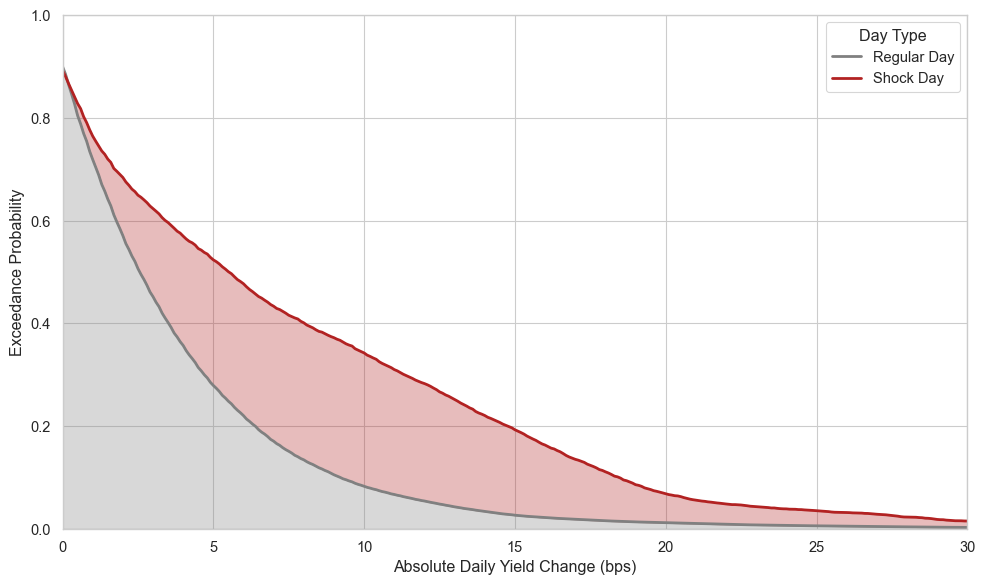

In [180]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# 1. Prepare Data
out['abs_delta_y'] = out['delta_y'].abs()
out['day_type'] = out['cds_shock_raw'].apply(lambda x: 'Shock Day' if x != 0 else 'Regular Day')

# 2. Define Continuous Thresholds
thresholds = np.linspace(0, 30, 301)

# 3. Calculate Exceedance Probabilities
results = []
shock_values = out[out['day_type'] == 'Shock Day']['abs_delta_y'].values
regular_values = out[out['day_type'] == 'Regular Day']['abs_delta_y'].values

for t in thresholds:
    results.append({
        'Threshold': t, 
        'Shock Day': np.mean(shock_values > t), 
        'Regular Day': np.mean(regular_values > t)
    })

df_plot = pd.DataFrame(results)

# 4. Plot
sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)
plt.figure(figsize=(10, 6))

# A. Base Risk (Regular Days)
# We plot the Gray line and fill everything below it as "Standard Market Risk"
plt.plot(df_plot['Threshold'], df_plot['Regular Day'], 
         color='gray', label='Regular Day', linewidth=2)
plt.fill_between(df_plot['Threshold'], 0, df_plot['Regular Day'], 
                 color='gray', alpha=0.3)

# B. Excess Risk (Shock Days)
# We plot the Red line, but we ONLY fill the area BETWEEN Gray and Red.
# This visually isolates the "Marginal Contribution" of the shock.
plt.plot(df_plot['Threshold'], df_plot['Shock Day'], 
         color='firebrick', label='Shock Day', linewidth=2)

plt.fill_between(df_plot['Threshold'], df_plot['Regular Day'], df_plot['Shock Day'],
                 where=(df_plot['Shock Day'] >= df_plot['Regular Day']),
                 color='firebrick', alpha=0.3, interpolate=True)

# 5. Formatting
plt.xlabel('Absolute Daily Yield Change (bps)')
plt.ylabel('Exceedance Probability')
plt.xlim(0, 30)
plt.ylim(0, 1)
plt.legend(title='Day Type')

plt.tight_layout()
plt.show()